In [1]:
import torch
import torchvision

In [28]:
n_epochs = 10
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.01
momentum = 0.5
log_interval = 10

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

In [ ]:
import os

DATA_ROOT = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                         '..', 'data_1')         
for candidate in ['./data_1', '../data_1', '/home/sakshi/Documents/GNR638/Assgn1/data_1']:
    if os.path.isdir(candidate):
        DATA_ROOT = candidate
        break

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((32, 32)),          
    torchvision.transforms.ToTensor(),         
    torchvision.transforms.Normalize(
        mean=(0.5, 0.5, 0.5),                   
        std =(0.5, 0.5, 0.5))
])

full_dataset = torchvision.datasets.ImageFolder(DATA_ROOT, transform=transform)


n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_test  = n_total - n_train
train_subset, test_subset = torch.utils.data.random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(random_seed)
)

train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=batch_size_train, shuffle=True)

test_loader  = torch.utils.data.DataLoader(
    test_subset,  batch_size=batch_size_test,  shuffle=False)

print(f"Dataset root : {DATA_ROOT}")
print(f"Classes      : {full_dataset.classes}")
print(f"Total images : {n_total}  |  Train: {n_train}  |  Test: {n_test}")

Dataset root : ../data_1
Classes      : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total images : 60000  |  Train: 48000  |  Test: 12000


In [ ]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

print("Batch shape :", example_data.shape)   
print("Labels shape:", example_targets.shape)

Batch shape : torch.Size([1000, 3, 32, 32])
Labels shape: torch.Size([1000])


In [12]:
example_data.shape

torch.Size([1000, 3, 32, 32])

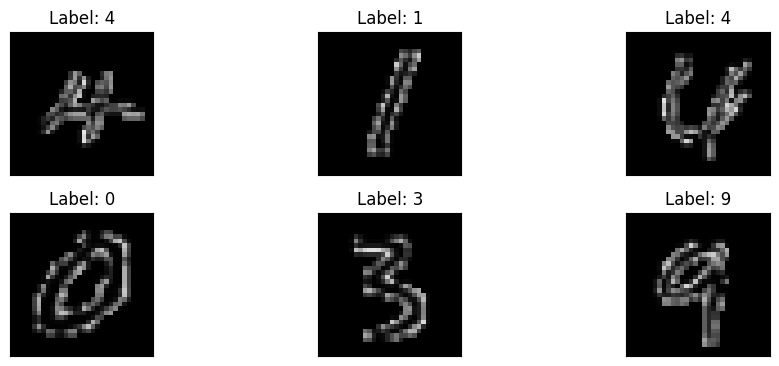

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.tight_layout()

    img = example_data[i].permute(1, 2, 0).numpy()   
    img = img * 0.5 + 0.5                             
    img = img.clip(0, 1)                              

    plt.imshow(img)                                   
    plt.title("Label: {}".format(example_targets[i].item()))
    plt.xticks([])
    plt.yticks([])
plt.show()

In [14]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [21]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(500, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 500)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [22]:
network = Net()
optimizer = optim.SGD(network.parameters(), lr=learning_rate,
                      momentum=momentum)

In [ ]:
train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

In [24]:
def train(epoch):
  network.train()
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = network(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    if batch_idx % log_interval == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset),
        100. * batch_idx / len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append(
        (batch_idx*batch_size_train) + ((epoch-1)*len(train_loader.dataset)))
      torch.save(network.state_dict(), 'model.pth')
      torch.save(optimizer.state_dict(), 'optimizer.pth')

In [25]:
def test():
  network.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = network(data)
      test_loss += F.nll_loss(output, target, reduction='sum').item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  test_losses.append(test_loss)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [29]:
test()
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()


Test set: Avg. loss: 0.3294, Accuracy: 10846/12000 (90%)

Train Epoch: 1 [0/48000 (0%)]	Loss: 0.541686
Train Epoch: 1 [640/48000 (1%)]	Loss: 0.538826
Train Epoch: 1 [1280/48000 (3%)]	Loss: 0.647371
Train Epoch: 1 [1920/48000 (4%)]	Loss: 0.840190
Train Epoch: 1 [2560/48000 (5%)]	Loss: 0.635435
Train Epoch: 1 [3200/48000 (7%)]	Loss: 0.840092
Train Epoch: 1 [3840/48000 (8%)]	Loss: 0.848157
Train Epoch: 1 [4480/48000 (9%)]	Loss: 0.353070
Train Epoch: 1 [5120/48000 (11%)]	Loss: 0.891709
Train Epoch: 1 [5760/48000 (12%)]	Loss: 0.431141
Train Epoch: 1 [6400/48000 (13%)]	Loss: 0.618564
Train Epoch: 1 [7040/48000 (15%)]	Loss: 0.621299
Train Epoch: 1 [7680/48000 (16%)]	Loss: 0.419251
Train Epoch: 1 [8320/48000 (17%)]	Loss: 0.481124
Train Epoch: 1 [8960/48000 (19%)]	Loss: 0.619376
Train Epoch: 1 [9600/48000 (20%)]	Loss: 0.655035
Train Epoch: 1 [10240/48000 (21%)]	Loss: 0.512803
Train Epoch: 1 [10880/48000 (23%)]	Loss: 0.625030
Train Epoch: 1 [11520/48000 (24%)]	Loss: 0.560212
Train Epoch: 1 [121

ValueError: x and y must be the same size

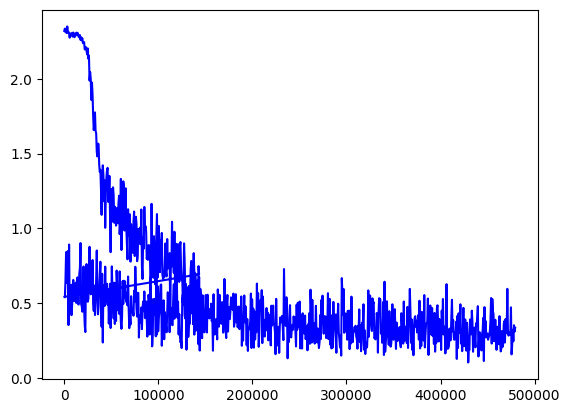

In [ ]:
# fig = plt.figure()
# plt.plot(train_counter, train_losses, color='blue')
# plt.scatter(test_counter, test_losses, color='red')
# plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
# plt.xlabel('number of training examples seen')
# plt.ylabel('negative log likelihood loss')
# fig.show()

In [37]:
with torch.no_grad():
  output = network(example_data)

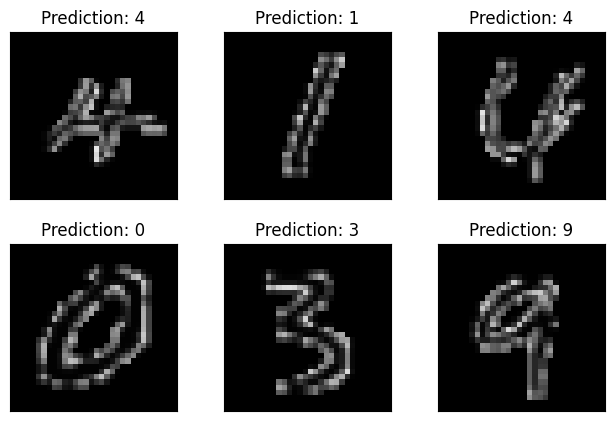

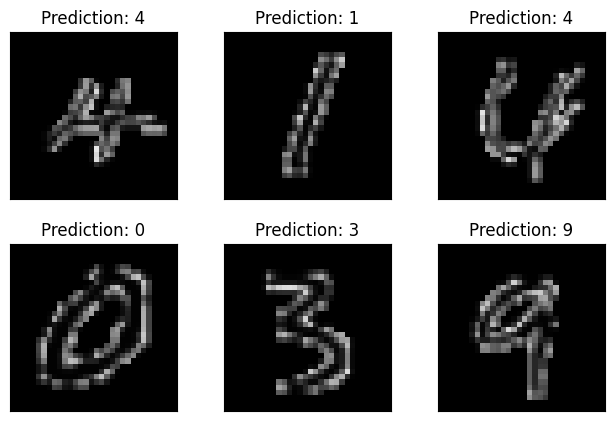

In [36]:
fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  img = example_data[i].permute(1, 2, 0).numpy()
  img = img * 0.5 + 0.5
  img = img.clip(0, 1)
  plt.imshow(img, interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
fig